````{margin}
```{attributiongrey} Attribution
:class: attribution

This page is adapted from https://github.com/twrijsdijk/Examples-for-the-use-of-springs-in-SymPy/blob/main/Vb_veerinbalk_midden.py

```
```` 


# Voorbeeld veer in balk midden

In [ ]:
%pip install git+https://github.com/twrijsdijk/sympy

belasting 100*SingularityFunction(x, 0, -1)/3 - 200*SingularityFunction(x, 3, -4)/3 - 100*SingularityFunction(x, 4, -1) + 200*SingularityFunction(x, 6, -1)/3
Dwarskrachten -100*SingularityFunction(x, 0, 0)/3 + 200*SingularityFunction(x, 3, -3)/3 + 100*SingularityFunction(x, 4, 0) - 200*SingularityFunction(x, 6, 0)/3
Reactiekrachten {R_0: 100/3, R_6: 200/3}
Moment -100*SingularityFunction(x, 0, 1)/3 + 200*SingularityFunction(x, 3, -2)/3 + 100*SingularityFunction(x, 4, 1) - 200*SingularityFunction(x, 6, 1)/3
Hoeverdraaiing SingularityFunction(x, 0, 2)/24 - SingularityFunction(x, 3, -1)/6 - SingularityFunction(x, 4, 2)/8 + SingularityFunction(x, 6, 2)/12 - 5/12
Doorbuiging -5*x/12 + SingularityFunction(x, 0, 3)/72 - SingularityFunction(x, 3, 0)/6 - SingularityFunction(x, 4, 3)/24 + SingularityFunction(x, 6, 3)/36


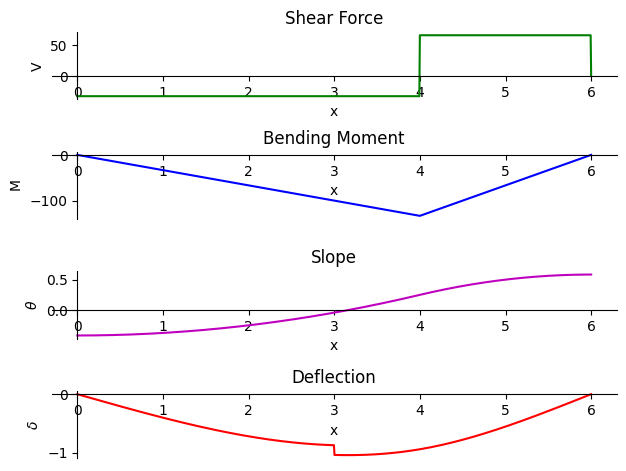

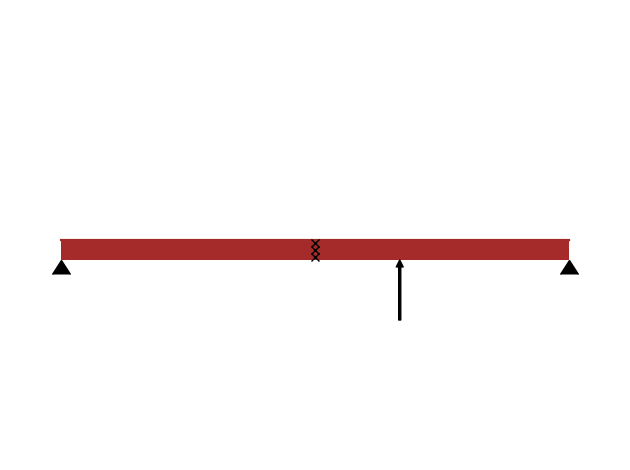

In [1]:
from sympy.physics.continuum_mechanics import Beam
from sympy import symbols
E, I, k = symbols(['E','I','k'])
#Omschrijving van de balk
b = Beam(6, 20, 20)
r0 = b.apply_support(0,'pin')
r6 = b.apply_support(6,'pin')
b.apply_load(-100, 4, -1)
b.apply_spring(3, 200)

#berekeningen
b.solve_for_reaction_loads(r0, r6)
print('belasting', b.load)
print('Dwarskrachten', b.shear_force())
print('Reactiekrachten', b.reaction_loads)
print('Moment',b.bending_moment())
print('Hoeverdraaiing',b.slope())
print('Doorbuiging',b.deflection())

#plots
axes = b.plot_loading_results()
d = b.draw()
d.show()